In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!python -m pip show tensorflow

Name: tensorflow
Version: 2.10.1
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\users\s1ndbad\anaconda3\envs\tf_gpu\lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, keras-preprocessing, libclang, numpy, opt-einsum, packaging, protobuf, setuptools, six, tensorboard, tensorflow-estimator, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: 


In [3]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))


2.10.1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from tensorflow.python.platform import build_info as tf_build_info
print("CUDA:", tf_build_info.build_info["cuda_version"])
print("cuDNN:", tf_build_info.build_info["cudnn_version"])

CUDA: 64_112
cuDNN: 64_8


In [ ]:
# !pip uninstall tensorflow tensorflow-intel -y
# !pip install tensorflow==2.10.1


In [ ]:
#!pip uninstall -y numpy scipy
#!pip install numpy==1.23.5 scipy==1.9.3


In [ ]:
#!pip uninstall -y scipy


In [ ]:
#!pip install scipy==1.10.1 --no-cache-dir


In [5]:
import tensorflow as tf
from tensorflow.keras.losses import Loss
from tensorflow.keras import backend as K

class CategoricalFocalLoss(Loss):
    """
    Categorical focal loss for one-hot labels.
    Usage:
        loss = CategoricalFocalLoss(gamma=2.0, alpha=0.25)
        model.compile(..., loss=loss, ...)
    """
    def __init__(self, gamma=2.0, alpha=0.25, from_logits=False, reduction=tf.keras.losses.Reduction.AUTO, name="categorical_focal_loss"):
        super().__init__(reduction=reduction, name=name)
        self.gamma = float(gamma)
        self.alpha = float(alpha) if alpha is not None else None
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        """
        y_true: one-hot (batch, classes)
        y_pred: probabilities (softmax) or logits if from_logits=True
        """
        # If logits provided, convert to probabilities
        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        # Clip to avoid log(0) and NaNs
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1.0 - eps)

        # Compute cross-entropy per class
        cross_entropy = -y_true * K.log(y_pred)  # shape (batch, classes)

        # get p_t: the model probability for the true class per sample (elementwise y_true * y_pred)
        p_t = y_true * y_pred  # (batch, classes)

        # focal weighting: (1 - p_t)^gamma
        focal_factor = K.pow(1.0 - p_t, self.gamma)

        if self.alpha is not None:
            alpha_factor = y_true * self.alpha + (1.0 - y_true) * (1.0 - self.alpha)
            # For multiclass one-hot alpha factor reduces to alpha for true class; keep simple:
            alpha_factor = y_true * self.alpha  # only apply alpha to true class entries
        else:
            alpha_factor = 1.0

        # elementwise focal loss
        loss = alpha_factor * focal_factor * cross_entropy  # (batch, classes)

        # sum over classes then mean over batch
        loss = K.sum(loss, axis=-1)
        return K.mean(loss)

    def get_config(self):
        return {"gamma": self.gamma, "alpha": self.alpha, "from_logits": self.from_logits}


In [6]:
import numpy as np
y_true = np.array([[1,0,0],[0,1,0]], dtype=np.float32)        # two samples, 3 classes
y_pred_good = np.array([[0.9,0.05,0.05],[0.05,0.9,0.05]], dtype=np.float32)
y_pred_bad  = np.array([[0.34,0.33,0.33],[0.34,0.33,0.33]], dtype=np.float32)

loss_fn = CategoricalFocalLoss(gamma=2.0, alpha=0.25)
print("good pred loss:", loss_fn(y_true, y_pred_good).numpy())
print("bad pred loss :", loss_fn(y_true, y_pred_bad).numpy())


good pred loss: 0.0002634015
bad pred loss : 0.120951


In [7]:
import cv2
import zipfile
import hashlib

from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import EfficientNetB3
from sklearn.utils.class_weight import compute_class_weight
#from tensorflow.keras.losses import CategoricalFocalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D, LeakyReLU, AveragePooling2D
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix

In [8]:
from pathlib import Path
import os
import shutil
import random

Split data into folders

In [9]:
#script_path = os.path.dirname(os.path.abspath(__file__))
script_path = ""
original_folder = os.path.join(script_path, "EuroSAT_RGB")
base_folder = os.path.join(script_path, "EuroSAT_RGB_split")

In [10]:
def split_data():
    train_ratio = 0.7
    val_ratio = 0.15
    random_state = 42
    random.seed(random_state)

    for split in ["train", "validate", "test"]:
        os.makedirs(os.path.join(base_folder, split), exist_ok=True)
    
    for class_name in os.listdir(original_folder):
        class_path = os.path.join(original_folder, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".png", ".tif"))]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        splits = {
            "train": images[:n_train],
            "validate": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for split_name, split_images in splits.items():
            split_dir = os.path.join(base_folder, split_name, class_name)
            os.makedirs(split_dir, exist_ok=True)

            for img_name in split_images:
                src = os.path.join(class_path, img_name)
                dst = os.path.join(split_dir, img_name)
                shutil.copy(src, dst)

        print(f"{class_name}: {n_total} images split into train/val/test")

In [11]:
#split_data()
# took 3 mins

AnnualCrop: 3000 images split into train/val/test

Forest: 3000 images split into train/val/test

HerbaceousVegetation: 3000 images split into train/val/test

Highway: 2500 images split into train/val/test

Industrial: 2500 images split into train/val/test

Pasture: 2000 images split into train/val/test

PermanentCrop: 2500 images split into train/val/test

Residential: 3000 images split into train/val/test

River: 2500 images split into train/val/test

SeaLake: 3000 images split into train/val/test


In [12]:
train_dir = os.path.join(base_folder, "train")
val_dir = os.path.join(base_folder, "validate")
test_dir = os.path.join(base_folder, "test")

In [13]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

Found 18900 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.


In [14]:
# import tensorflow as tf
# print("TensorFlow version:", tf.__version__)
# print("GPUs available:", tf.config.list_physical_devices('GPU'))

In [15]:
# import os, tensorflow as tf
# print(tf.sysconfig.get_build_info()["cuda_version"])
# print(tf.sysconfig.get_build_info()["cudnn_version"])

In [16]:
# from tensorflow.python.platform import build_info
# print(build_info.build_info)


In [17]:
from IPython.display import display, Javascript
display(Javascript('google.colab.output.setIframeHeight(0, true, {maxHeight: 30000})'))
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"
os.environ["TF_FORCE_CONSOLE_LOG"] = "1"


<IPython.core.display.Javascript object>

In [25]:
class_labels = train_generator.classes
class_weight_dict = dict(
    enumerate(
        compute_class_weight('balanced', classes=np.unique(class_labels), y=class_labels)
    )
)

model = Sequential([
    *[
        layer
        for filters in [64, 128, 256, 512]
        for layer in (
            [Conv2D(filters, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001)),
             BatchNormalization(),
             MaxPooling2D(2)]
        )
    ],
    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

print("before CategoricalFocalLoss")
focal_loss = CategoricalFocalLoss(gamma=2.0, alpha=0.25, from_logits=False)

print("before Model Compile")
model.compile(
    optimizer=Adam(1e-4),
    loss=focal_loss,
    metrics=['accuracy']
)

# model.compile(
#     optimizer=Adam(1e-4),
#     loss=CategoricalFocalCrossentropy(gamma=2.0),
#     metrics=['accuracy']
# )

callbacks = [
    ModelCheckpoint(
        'checkpoints/best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)
]
print("before training")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print("after training")


before CategoricalFocalLoss
before Model Compile
before training
Epoch 1/50
591/591 [==============================] - ETA: 0s - loss: 1.0282 - accuracy: 0.6776
Epoch 1: val_loss improved from inf to 1.15865, saving model to checkpoints\best_model.keras
591/591 [==============================] - 14s 21ms/step - loss: 1.0282 - accuracy: 0.6776 - val_loss: 1.1587 - val_accuracy: 0.4267 - lr: 1.0000e-04
Epoch 2/50
589/591 [============================>.] - ETA: 0s - loss: 0.8438 - accuracy: 0.7795
Epoch 2: val_loss improved from 1.15865 to 0.76792, saving model to checkpoints\best_model.keras
591/591 [==============================] - 12s 20ms/step - loss: 0.8437 - accuracy: 0.7794 - val_loss: 0.7679 - val_accuracy: 0.8015 - lr: 1.0000e-04
Epoch 3/50
590/591 [============================>.] - ETA: 0s - loss: 0.7011 - accuracy: 0.8258
Epoch 3: val_loss improved from 0.76792 to 0.63391, saving model to checkpoints\best_model.keras
591/591 [==============================] - 12s 21ms/step - l

In [26]:
model.save("SataliteClassification.keras")
#loaded_model = tf.keras.models.load_model("SataliteClassification.keras")

test

In [27]:
def evaluate_model(model, test_ds, class_names):
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"\nTest Results:\nAccuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

    preds = model.predict(test_ds, verbose=1)
    y_pred = np.argmax(preds, axis=1)

    if hasattr(test_ds, 'labels'):
        y_true = test_ds.labels
    else:
        y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds], axis=0)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    print('\nClassification Report:\n')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return test_acc, test_loss, y_true, y_pred


Test Results:
Accuracy: 0.9733 | Loss: 0.0312
127/127 [==============================] - 2s 14ms/step


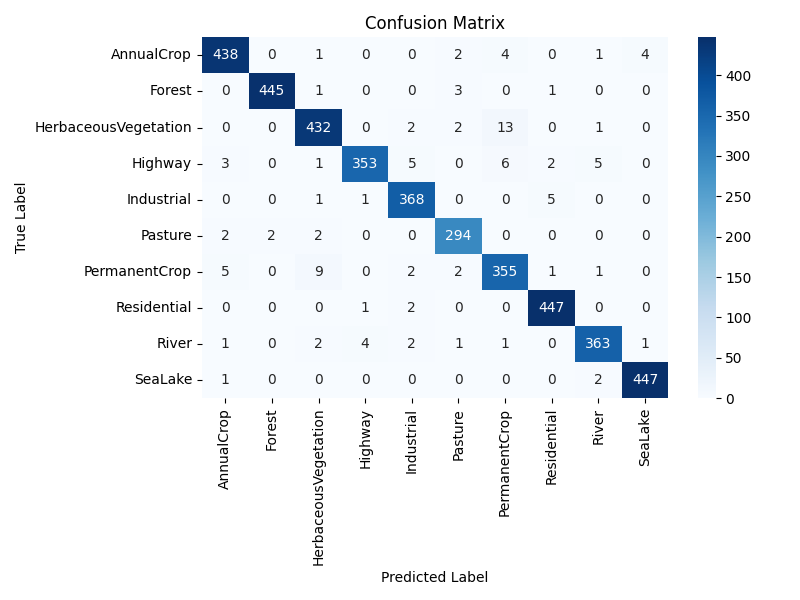


Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.9733    0.9733    0.9733       450
              Forest     0.9955    0.9889    0.9922       450
HerbaceousVegetation     0.9621    0.9600    0.9611       450
             Highway     0.9833    0.9413    0.9619       375
          Industrial     0.9659    0.9813    0.9735       375
             Pasture     0.9671    0.9800    0.9735       300
       PermanentCrop     0.9367    0.9467    0.9416       375
         Residential     0.9803    0.9933    0.9868       450
               River     0.9732    0.9680    0.9706       375
             SeaLake     0.9889    0.9933    0.9911       450

            accuracy                         0.9733      4050
           macro avg     0.9726    0.9726    0.9726      4050
        weighted avg     0.9734    0.9733    0.9733      4050

Test Accuracy: 0.9733
Test Loss: 0.0312


In [28]:
test_acc, test_loss, y_true, y_pred = evaluate_model(model, test_generator, list(test_generator.class_indices.keys()))
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

In [29]:
def plot_training_curves(model, test_acc=0):
    acc = model.history['accuracy']
    val_acc = model.history['val_accuracy']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.axhline(y=test_acc, linestyle='--', color='green', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

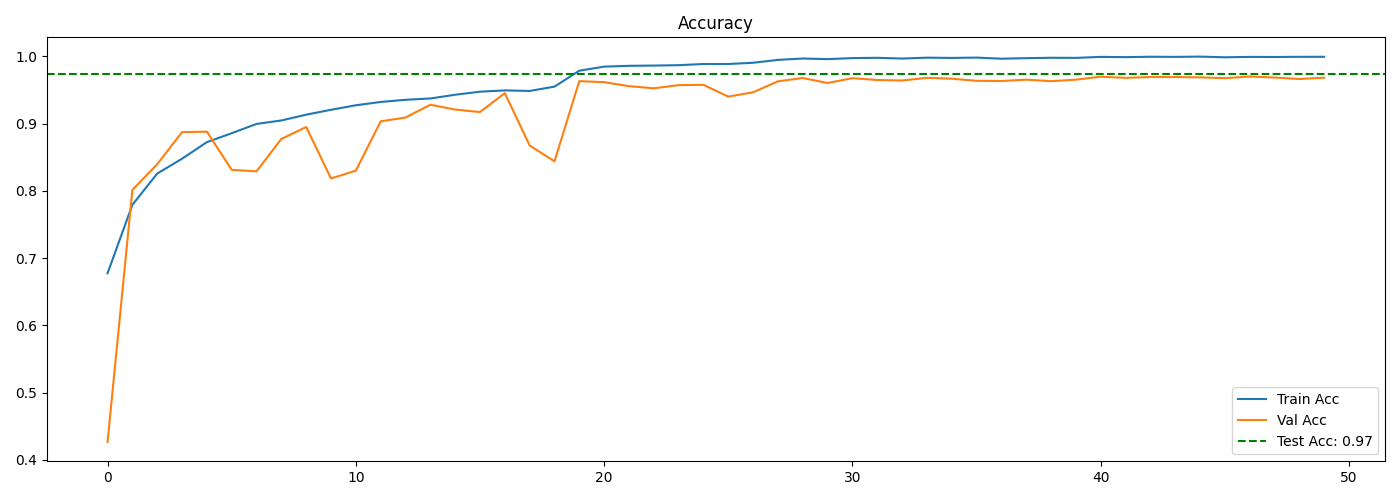

In [30]:
plot_training_curves(history, test_acc=test_acc)

In [31]:
split_dir = r"D:\Coding\Jupyter\DEPI\DEPI-Final-Project\Dataset\Project 6 Datasets\EuroSAT_RGB_split\test"
img_size = (64, 64)
class_names = list(test_generator.class_indices.keys())

all_image_paths = []
for class_dir in os.listdir(split_dir):
    class_path = os.path.join(split_dir, class_dir)
    if os.path.isdir(class_path):
        for fname in os.listdir(class_path):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(class_path, fname))

random_image_path = random.choice(all_image_paths)
image_type = random_image_path.split("\\")[-1]
print(f"Randomly selected image: {image_type}")

img = cv2.imread(random_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, img_size)
img_array = np.expand_dims(img_resized, axis=0) / 255.0  # normalize

pred = model.predict(img_array)
pred_class = class_names[np.argmax(pred)]

plt.imshow(img)
plt.title(f"Predicted: {pred_class}")
plt.axis('off')
plt.show()

print(f"\nModel prediction: {pred_class}")

Randomly selected image: Forest_884.jpg


AttributeError: module 'cv2' has no attribute 'imread'